# FIRST PART

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("cardio_train.csv", sep=";")

df.shape

df.head()

df.info()
df.describe()

df["cardio"].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


cardio
0    35021
1    34979
Name: count, dtype: int64

In [10]:
df["age_years"] = (df["age"] / 365).round(1)

Is the target balanced? If one class dominates, accuracy becomes meaningless.

In [6]:
df["cardio"].value_counts(normalize=True)

cardio
0    0.5003
1    0.4997
Name: proportion, dtype: float64

Are the value ranges realistic? Real data has typos. Typos can posion our model, if they are not cleaned.

In [7]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700,53.339486
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003,6.759534
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,29.600000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,48.400000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,54.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,58.400000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,65.000000


In [4]:
df["ap_hi"].describe([.01, .25, .5, .75, .99])

count    70000.000000
mean       128.817286
std        154.011419
min       -150.000000
1%          90.000000
25%        120.000000
50%        120.000000
75%        140.000000
99%        180.000000
max      16020.000000
Name: ap_hi, dtype: float64

## What shape do the distributions have?

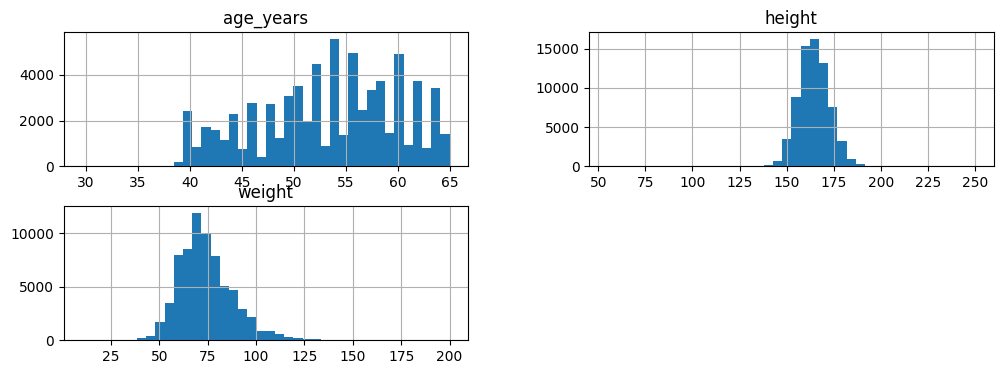

In [11]:
df[["age_years","height","weight"]].hist(bins=40, figsize=(12,4))
plt.show()

## Which features change between sick and healthy patients?


In [25]:
df.groupby("cardio")[["age_years","height","weight","ap_hi","ap_lo","smoke","alco","active"]].mean()



,age_years,height,weight,ap_hi,ap_lo,smoke,alco,active
cardio,,,,,,,,
0,51.730770,164.448017,71.592150,120.432598,84.251763,0.092516,0.055424,0.817881
1,54.950133,164.270334,76.822368,137.212042,109.023929,0.083736,0.052117,0.789559


In [26]:
pd.crosstab(df["cardio"], df["cholesterol"], normalize="index")


cholesterol,1,2,3
cardio,,,
0,0.837498,0.108478,0.054025
1,0.659110,0.164384,0.176506


## Which features correlate with the target — and with each other?

<Axes: >

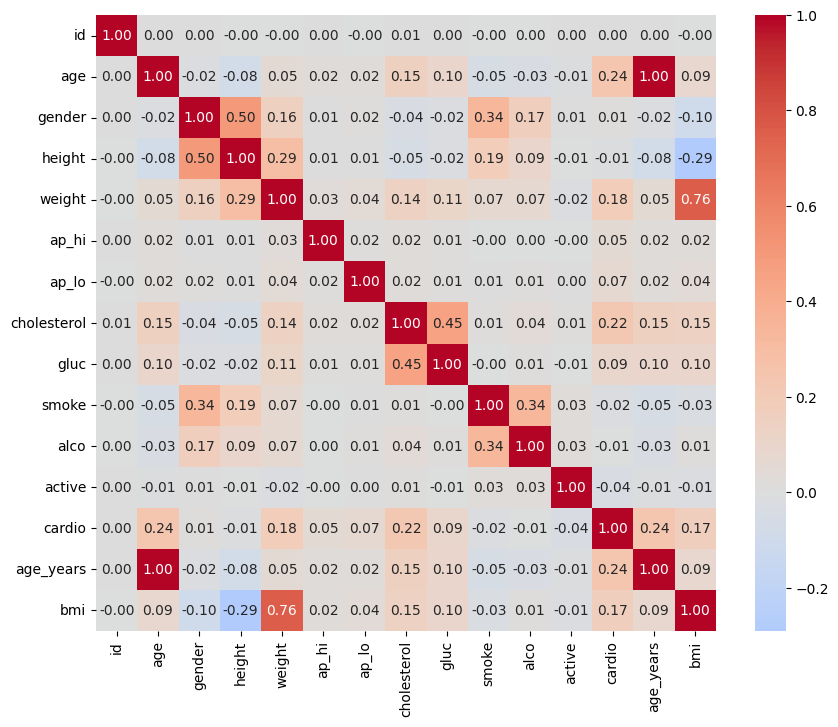

In [30]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)

## Can I engineer a stronger feature?

In [29]:
df["bmi"] = df["weight"] / (df["height"]/100)**2

# SECOND PART

**Cleaning and preprocessing ,cleaning means throwing out garbage rows, preprocessing means process what is left in order for the model to learn from it**

### 1 - Remove Garbage Rows

In [35]:
df_clean = df[
    df["ap_hi"].between(90, 200) &
    df["ap_lo"].between(60, 130) &
    (df["ap_hi"] > df["ap_lo"]) &
    df["height"].between(140, 210) &
    df["weight"].between(40, 160)
].copy()

print(f"Before: {len(df):,}")
print(f"After:  {len(df_clean)from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=["No CVD", "CVD"])):,}")
print(f"Dropped: {len(df) - len(df_clean):,} rows ({(1 - len(df_clean)/len(df))*100:.1f}%)")

Before: 70,000
After:  68,210
-68209
Dropped: 1,790 rows (2.6%)


Imputation is better when you have empty data instead of wrong data. This is the reason why we remove the wrong rows instead of imputing new ones.

### 2 - Engineer new features

In [36]:
df_clean["bmi"] = df_clean["weight"] / (df_clean["height"] / 100) ** 2
df_clean["pulse_pressure"] = df_clean["ap_hi"] - df_clean["ap_lo"]

# We remove age here, because the age_years is better for the model
df_clean = df_clean.drop(columns=["age"])  

Sometimes new column that is created by existing ones carries more valuable information.

In [37]:
df_clean.groupby("cardio")[["bmi", "pulse_pressure", "age_years"]].mean()

,bmi,pulse_pressure,age_years
cardio,,,
0,26.451229,41.480696,51.729325
1,28.428768,49.256057,54.965796


### 3 - Encoding categorical features

Models eat numbers, not categories. We have already encoded integers. If a column we nominal like blood type 1 = A, 2 = B, 3 = AB , 4 = O,  feeding 1/2/3/4 to the model would invent a fake ordering, implying O is more than A is non-sense. 

### 4 - Seperate features from target


It is a convention so the X is called the feature matrix and y is called the target vector. In this dataset is easy to set that the target vector is the cardio column, and the feature matrix is every column except that


In [38]:
X = df_clean.drop(columns = "cardio")
y = df_clean['cardio']
print(X.shape, y.shape)
X.head()

(68210, 14) (68210,)


,id,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,age_years,bmi,pulse_pressure
0,0,2,168,62.0,110,80,1,1,0,0,1,50.4,21.967120,30
1,1,1,156,85.0,140,90,3,1,0,0,1,55.4,34.927679,50
2,2,1,165,64.0,130,70,3,1,0,0,0,51.7,23.507805,60
3,3,2,169,82.0,150,100,1,1,0,0,1,48.3,28.710479,50
4,4,1,156,56.0,100,60,1,1,0,0,0,47.9,23.011177,40


# THIRD PART

### 1 - Train, test and split

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]:,} patients")
print(f"Test:  {X_test.shape[0]:,} patients")

Train: 54,568 patients
Test:  13,642 patients


Always in classification set stratify = y to preserve the class balance in both sets (training and testing), getting the ~50/50 CVD in both sets

### 2 - Scaling

We scale, using standardization in this case,so each feature gets transformed so its mean is 0 and its standard deviation is 1.
The formula for standardization is **(value − mean) / std**. After scaling each feature sits on a comparable scale and gradient descent converges fast and stably.

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   

We fit_transform, meaning we find the mean and std from this data and apply the transformation in the trainging data. We transform, meaning we apply computed mean and std to unknown values, test data. 

# FOURTH PART

In [43]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

max_iter is the parameter that determines or set the limit for the number of gradient steps allowed

After model has learned, we inspect the coefficient it used during the process.

### 2 - Study coefficients

In [45]:
import pandas as pd

coefficients = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False)

print(coefficients)
print(f"\nIntercept (bias): {model.intercept_[0]:.4f}")

           feature  coefficient
4            ap_hi     0.446394
5            ap_lo     0.375545
11       age_years     0.353333
13  pulse_pressure     0.335214
6      cholesterol     0.328973
3           weight     0.309737
12             bmi    -0.156084
2           height    -0.099955
10          active    -0.088073
7             gluc    -0.061390
9             alco    -0.055884
8            smoke    -0.040515
1           gender    -0.014449
0               id     0.005637

Intercept (bias): 0.0278


Each coefficient tells us the strength and the direction it has on the CVD risk. Meaning:
1 - Positive coefficients -> Higher value pushes prediction toward CVD
2 - Negative coefficients -> Higher value pushes prediction away CVD
3 - Magnitude -> Bigger, stronger the influence

### 3 - Make predictions

In [46]:
# Slice the first index to get the CVD probability 
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred = model.predict(X_test_scaled)

print("Predicted P(CVD):", y_pred_proba[:10].round(3))
print("Predicted class: ", y_pred[:10])
print("Actual class:    ", y_test.values[:10])

Predicted P(CVD): [0.689 0.079 0.603 0.226 0.73  0.27  0.843 0.8   0.41  0.158]
Predicted class:  [1 0 1 0 1 0 1 1 0 0]
Actual class:     [0 0 1 0 0 0 1 1 0 0]


# FIFTH PART

### 1 - Why the accuaracy alone is not enough

A model with 80% accuracy could be making mostly the first kind of mistake (catastrophic) or as we call it false negative or mostly the second (acceptable) false positive. Accuracy can't tell the difference. So we use a small family of metrics that can.

### 2 - The confusion matrix, the source of everything

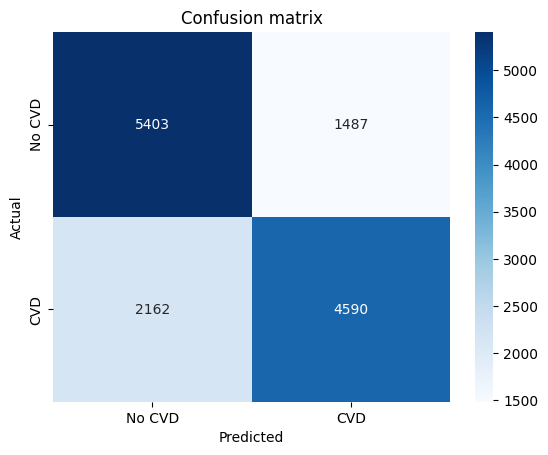

In [47]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No CVD", "CVD"],
            yticklabels=["No CVD", "CVD"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix")
plt.show()

True Negative (TN) = Top Left, predicted no CVD or he is healthy, he has no CVD or he is healthy
False Positive (FP) = Top Right, predicted has CVD or he is not healthy,he has no CVD or instead he is healthy
False Negative (FN) = Bottom Left, no CVD or predicted healthy, has CVD or he is not healthy
True Positive (TP) = Bottom Right, CVD or not health, has CVD and is not healthy

### 3 - Accuracy, precision, recall, F1

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1 score:  {f1_score(y_test, y_pred):.3f}")

In [ ]:
Accuracy = (TP + TN) / total - overall what fraction did I get right

In [ ]:
Precision = TP / (TP + FP) - of patients i flagged as CVD, what fraction actually has CVD. High precision = few false alarms

In [ ]:
Recall = TP / TP + FN - of patients that have CVD, what fraction did I actually caught. High recall = few missed cases.

In [ ]:
F1 - Harmonic mean of precision and recall

### 4 - The precision–recall tradeoff

If we lower the threshold we should caught more false positives. Meaning less precision greater recall. The vice versa phenomenon happens if we rist the threeshold. 

### 5 -  ROC - AUC - the threeshold free matrix

In [ ]:
Since threshold is a knob, is better to evaluate the model independent of which threshold you pick. 

ROC-AUC: 0.793


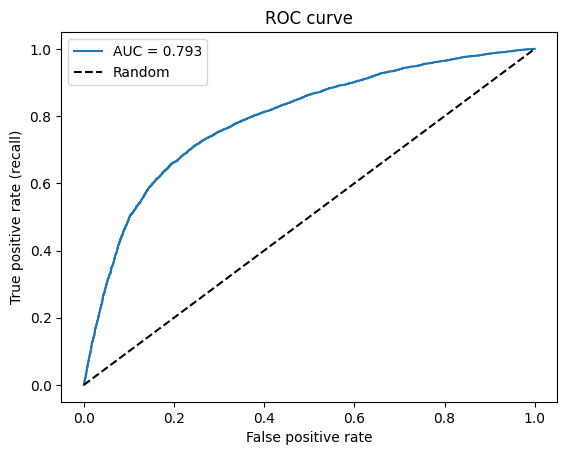

In [48]:
from sklearn.metrics import roc_auc_score, roc_curve

auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC: {auc:.3f}")

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate (recall)")
plt.title("ROC curve")
plt.legend()
plt.show()

The intuition: AUC = "if I pick one CVD patient and one healthy patient at random, what's the probability the model assigns higher P(CVD) to the sick one?" That's why it doesn't

### 6 - The full picture in one call

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=["No CVD", "CVD"]))

Classification report give you an overall insight on precision, recall, f1, 

# SIXTH PART

In [ ]:
Note: Recall and precision depend on the threshold.

### 1 - Tune the threshold on what you already have

Best threshold: 0.416
At that threshold — precision: 0.686, recall: 0.789, F1: 0.734


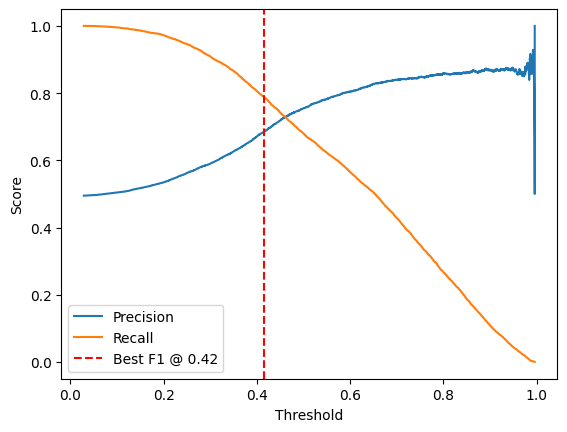

In [55]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1s = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1s)
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.3f}")
print(f"At that threshold — precision: {precisions[best_idx]:.3f}, recall: {recalls[best_idx]:.3f}, F1: {f1s[best_idx]:.3f}")

plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.axvline(best_threshold, color="red", linestyle="--", label=f"Best F1 @ {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend(); plt.show()

### 2 - Train stronger models

Logistic regression draws a straight line through feature space. Real CVD risk is not linear, Real CVD risk isn't linear — risk from high blood pressure interacts with age, BMI interacts with cholesterol, and so on. Tree-based models capture these interactions automatically.

#### 1 -Random forest — many decision trees, each trained on a random subset of data and features, voting together. Robust, little tuning needed.

In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report

rf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

rf_proba = rf.predict_proba(X_test_scaled)[:, 1]
print(f"Random forest AUC: {roc_auc_score(y_test, rf_proba):.3f}")

Random forest AUC: 0.802


#### 2 - Gradient boosting — trees built sequentially, each one fixing the previous one's mistakes. Usually the top performer on tabular data

In [58]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
gb.fit(X_train_scaled, y_train)

gb_proba = gb.predict_proba(X_test_scaled)[:, 1]
print(f"Gradient boosting AUC: {roc_auc_score(y_test, gb_proba):.3f}")

Gradient boosting AUC: 0.802


These are the key parameters:

n_estimators — number of trees. More trees = better
max_depth — how deep each tree can grow. Deeper = more complex patterns captured, but higher overfitting risk.
learning_rate (boosting only) — how strongly each new tree corrects the previous mistakes. Lower = slower learning but more stable.

### 3 - Hyperparameter tuning

In [65]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 10, 20],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train_scaled, y_train)

print(f"Best params: {grid.best_params_}")
print(f"Best CV AUC: {grid.best_score_:.3f}")
best_rf = grid.best_estimator_

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best params: {'max_depth': 10, 'min_samples_split': 20, 'n_estimators': 300}
Best CV AUC: 0.799


Grid search — GridSearchCV tries every combination in param_grid (3 × 3 × 3 = 27 here) and picks the best. Exhaustive, slow, but thorough. For larger search spaces, RandomizedSearchCV samples random combinations instead — much faster, almost as good.

Cross-validation — the cv=5 is the more important concept. Instead of judging each combo on a single train/test split (which is noisy), it splits the training set into 5 folds, trains on 4 and validates on 1, rotates 5 times, averages the scores. The result is far more reliable than a single split. 

### 4 - Discipline of comparing

In [ ]:
Here we need to pick the winner method.

In [66]:
from sklearn.metrics import roc_auc_score

models = {
    "Logistic regression": y_pred_proba,
    "Random forest":       rf_proba,
    "Gradient boosting":   gb_proba,
    "Tuned random forest": best_rf.predict_proba(X_test_scaled)[:, 1],
}

for name, proba in models.items():
    print(f"{name:25s} AUC: {roc_auc_score(y_test, proba):.3f}")

Logistic regression       AUC: 0.793
Random forest             AUC: 0.802
Gradient boosting         AUC: 0.802
Tuned random forest       AUC: 0.802


# SEVENTH STEP

Final step: understand what the model learned, check that its probabilities are trustworthy, and save it for reuse. We do three things — read feature importances to see what drives predictions, plot a calibration curve to confirm the probabilities mean what they say, and persist both the model and the scaler so we can score new patients later without retraining.


In [ ]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import calibration_curve

importances = pd.DataFrame({
    "feature": X.columns,
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False)

sns.barplot(data=importances, x="importance", y="feature")
plt.title("Feature importance")
plt.tight_layout(); plt.show()

proba = best_rf.predict_proba(X_test_scaled)[:, 1]
prob_true, prob_pred = calibration_curve(y_test, proba, n_bins=10)

plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
plt.xlabel("Mean predicted probability"); plt.ylabel("Actual fraction with CVD")
plt.title("Calibration curve"); plt.legend(); plt.show()

joblib.dump(best_rf, "cvd_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("Saved: cvd_model.pkl, scaler.pkl")

new_patient = pd.DataFrame([{
    "age_years": 55, "gender": 1, "height": 170, "weight": 80,
    "ap_hi": 140, "ap_lo": 90, "cholesterol": 2, "gluc": 1,
    "smoke": 0, "alco": 0, "active": 1,
    "bmi": 27.7, "pulse_pressure": 50
}])[X.columns]   

new_patient_scaled = scaler.transform(new_patient)
risk = best_rf.predict_proba(new_patient_scaled)[0, 1]
print(f"CVD risk for this patient: {risk:.1%}")